![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [1]:
import sys
import importlib

librerias_requeridas = {
  'numpy': 'numpy',
  'pandas': 'pandas',
  'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
  try:
    lib = importlib.import_module(modulo)
    version = getattr(lib, '__version__', 'versión no disponible')
    print(f'✓ {nombre} {version}')
  except ImportError:
    print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
    todo_ok = False

print('-' * 40)
if todo_ok:
  print('Entorno listo. Puede continuar con el laboratorio.')
else:
  print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.13.12 (main, Feb  4 2026, 00:05:32) [Clang 21.1.4 ]
----------------------------------------
✓ numpy 2.4.4
✓ pandas 3.0.2
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [2]:
import os
import time
import math
import random
import fcntl  # Usado para activar F_NOCACHE y reducir el efecto del page cache en macOS.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- **Respuesta 1:** En este laboratorio vamos a considerar que la latencia es el tiempo de espera que transcurre desde que se solicita un dato hasta que el disco realmente empieza a transferirlo. Para los HDDs incluye el tiempo que tarda el cabezal de lectura para moverse y para los SSDs el tiempo que tarda el controlador en localizar el bloque solicitado. 

- **Respuesta 2:** El throughput, traducido al español *"rendimiento*" es la rapidez real con la que se transfieren los datos desde el almacenamiento permanente hacia la memoria una vez ya ha sido localizado (latencia). Nos indica cuantos bytes por segundo se pueden transferir desde el disco por unidad del tiempo. 

- **Respuesta 3:** Asumimos que $M \approx 1$ porque al leer datos que están colocados de manera contigua el disco hace un esfuerzo grande solo en la lectura inicial del primer bloque y luego simplemente sigue leyendo de forma fluida debido a que no tiene que saltar a otras partes, este efecto se aprecia de manera más notoria en los HDDs.  

- **Respuesta 4:** Si queremos acceder a los datos con un patrón de acceso aleatorio, esto obligará a nuestro disco a realizar un nuevo proceso de localización para casi cada bloque que queremos leer, lo que hace que el número de accesos no contiguos sea alto.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [3]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 8192 # 8 GiB (No confundir con GB)

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Activa lecturas con hint anti-cache (macOS F_NOCACHE).
USE_COLD_IO = True

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)
print('Usar I/O en frío (sin caché):', USE_COLD_IO)

Archivo: io_lab_data/dataset.bin
Tamaño objetivo (MB): 8192
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000
Usar I/O en frío (sin caché): True


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- **Respuesta 1:** El archivo configurado es de **8192 MB**, lo cual representa exactamente **8 GiB** *(Gibibyte)*. Comparando con los *32 GB* de RAM unificada de mi laptop, el archivo claramente no es lo suficientemente grande para superar la caché del equipo. La RAM es varias veces más grande que este archivo, por lo que el sistema operativo podría optar por cargar los datos en memoria facilmente y acelerando las lecturas posteriores de manera *"artificial"*.  

- **Respuesta 2:** Se esperaría que el bloque de **256 KB** tubiera el mejor rendimiento en términos de throughput (MB/s). La razón es que en acceso aleatorio, cada salto tiene un costo de latencia fijo y al usar un bloque más grande estamos aprovechando cada uno de esos "saltos" para transferir más información.  

- **Respuesta 3:** Estoy ejecutando el notebook del laboratorio en mi laptop de trabajo (macOS con procesador ARM).

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [4]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = True  # Cambie a True para eliminar el archivo de prueba

if RESET:
  if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
    DATA_DIR.mkdir(exist_ok=True)
    print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
  else:
    print('No hay archivos previos que eliminar.')
else:
  print('RESET = False. No se eliminó ningún archivo.')
  print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

Carpeta io_lab_data eliminada. El archivo se recreará en la siguiente sección.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [5]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
  """Crea un archivo binario grande para pruebas de I/O.

  Parámetros:
      file_path: ruta del archivo a crear.
      size_mb: tamaño total del archivo en MB.
      chunk_mb: tamaño del bloque con el que se escribe el archivo.
  """
  target_size = size_mb * 1024 * 1024
  if file_path.exists() and file_path.stat().st_size == target_size:
    print('El archivo ya existe y tiene el tamaño esperado.')
    return

  print(f'Creando archivo de {size_mb} MB...')
  chunk_bytes = chunk_mb * 1024 * 1024
  remaining = target_size

  with open(file_path, 'wb') as f:
    while remaining > 0:
      current = min(chunk_bytes, remaining)
      f.write(os.urandom(current))
      remaining -= current

  print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 8192 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 8589934592


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- **Respuesta 1:** El archivo contiene nuestros datos de prueba, lo utilizamos para simular la información real que una base de datos o un sistema de archivos tendría guardada permanentemente. Sobre este archivo vamos a realizar diferentes operaciones de lectura con los distintos patrones de acceso que definimos anteriormente (acceso secuencial y acceso aleatorio) para medir que tanto le cuesta a nuestro sistema recuperar esos datos.  

- **Respuesta 2:** Al utilizar un archivo grande (como este de 8 GiB) forzamos que los tiempos de lectura sean lo suficientemente largos como para que los podamos medir con precisión. Esto nos ayuda a que el *throughput* del sistema sea estable y no fluctue desmedidamente.  

- **Respuesta 3:** Si el archivo fuera demasiado pequeño (por ejemplo 10 MB), el sistema operativo buscaría optimizar las lecturas del archivo almacenandolo en el **page cache** o **caché del SO**, esto causaría todas las pruebas realizadas después de la primerar lectura no sean válidas al medir realmente la velocidad de acceso a la RAM y no al disco.

## 5. Funciones auxiliares de medición

In [6]:
def format_bytes(num_bytes: int) -> str:
  """Convierte un tamaño en bytes a una representación legible."""
  units = ['B', 'KB', 'MB', 'GB', 'TB']
  value = float(num_bytes)
  for unit in units:
    if value < 1024 or unit == units[-1]:
      return f'{value:.2f} {unit}'
    value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
  """Calcula throughput en MiB/s."""
  if elapsed_seconds <= 0:
    return float('inf')
  return (total_bytes / (1024 * 1024)) / elapsed_seconds


def _enable_f_nocache_if_requested(file_obj) -> None:
  """Activa F_NOCACHE en macOS cuando USE_COLD_IO=True."""
  if not globals().get('USE_COLD_IO', False):
    return
  try:
    fcntl.fcntl(file_obj.fileno(), fcntl.F_NOCACHE, 1)
  except Exception:
    # Si no está disponible, continúa sin interrumpir la medición.
    pass


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
  """Mide lectura secuencial del archivo completo."""
  total_bytes = 0
  start = time.perf_counter()
  with open(file_path, 'rb', buffering=0) as f:
    _enable_f_nocache_if_requested(f)
    while True:
      chunk = f.read(block_size)
      if not chunk:
        break
      total_bytes += len(chunk)
  elapsed = time.perf_counter() - start
  return {
    'pattern': 'Secuencial',
    'block_size_bytes': block_size,
    'total_bytes': total_bytes,
    'operations': math.ceil(total_bytes / block_size),
    'elapsed_s': elapsed,
    'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
  }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
  """Mide lectura aleatoria de bloques en posiciones dispersas."""
  file_size = file_path.stat().st_size
  max_offset = file_size - block_size
  if max_offset <= 0:
    raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

  offsets = np.random.randint(0, max_offset + 1, size=reads)
  total_bytes = 0

  start = time.perf_counter()
  with open(file_path, 'rb', buffering=0) as f:
    _enable_f_nocache_if_requested(f)
    for offset in offsets:
      f.seek(int(offset))
      chunk = f.read(block_size)
      total_bytes += len(chunk)
  elapsed = time.perf_counter() - start
  return {
    'pattern': 'Aleatorio',
    'block_size_bytes': block_size,
    'total_bytes': total_bytes,
    'operations': reads,
    'elapsed_s': elapsed,
    'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
  }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [7]:
results = []

for block_size in BLOCK_SIZES:
  print(f'\nProbando bloque = {format_bytes(block_size)}')

  seq_result = sequential_read_measure(FILE_PATH, block_size)
  num_reads = FILE_PATH.stat().st_size // block_size
  rnd_result = random_read_measure(FILE_PATH, block_size, num_reads)

  results.append(seq_result)
  results.append(rnd_result)

  print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
  print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 42.0305 s, throughput: 194.91 MiB/s
Aleatorio  -> tiempo: 231.1767 s, throughput: 35.44 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 15.0178 s, throughput: 545.49 MiB/s
Aleatorio  -> tiempo: 63.3661 s, throughput: 129.28 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 17.6794 s, throughput: 463.37 MiB/s
Aleatorio  -> tiempo: 20.3542 s, throughput: 402.47 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 6.3874 s, throughput: 1282.52 MiB/s
Aleatorio  -> tiempo: 6.5910 s, throughput: 1242.91 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,8589934592,2097152,42.030503,194.906068,4.0
1,Aleatorio,4096,8589934592,2097152,231.176696,35.436098,4.0
2,Secuencial,16384,8589934592,524288,15.017750,545.487827,16.0
3,Aleatorio,16384,8589934592,524288,63.366147,129.280387,16.0
4,Secuencial,65536,8589934592,131072,17.679353,463.365384,64.0
5,Aleatorio,65536,8589934592,131072,20.354243,402.471376,64.0
6,Secuencial,262144,8589934592,32768,6.387426,1282.519842,256.0
7,Aleatorio,262144,8589934592,32768,6.590995,1242.907930,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

En estas mediciones se usa el flag `F_NOCACHE` del sistema operativo cuando `USE_COLD_IO = True` para reducir el efecto del page cache del sistema operativo, este flag le indica al kernel que al leer de dicho archivo no lo almacene en su memoria caché.

- **Respuesta 1:** Para poder comparar de manera justa, ajustamos el número de lecturas aleatorias de `random_read_measure` para que el número total de bytes leídos por ambos fuera similar. Con F_NOCACHE activado para descartar el page cache, el acceso secuencial fue más rápido en todos los tamaños de bloque. La diferencia se hace bastánte visible en bloques pequeños donde el costo de latencia domina.

  | Tamaño | Secuencial | Aleatorio |
  | ------ | ---------- | --------- |
  | 4 KB   | 42.03 s    | 231.18 s  |
  | 16 KB  | 15.01 s    | 63.37 s   |
  | 64 KB  | 17.68 s    | 20.35 s   |
  | 256 KB | 6.38 s     | 6.59 s    |

  Este comportamiento se alinea con el modelo de costo I/O visto en clase: la penalización del acceso aleatorio disminuye al aumentar el tamaño de bloque, y para bloques grandes ambos patrones no tienen mayores distinciones. Sin caché del SO interfiriendo, ahora vemos el comportamiento real del hardware.

- **Respuesta 2:** Sí, el throughput aumentó con el aumento de tamaño de bloque en ambos patrones. Esto es especialmente notable al pasar de 4 KB a 256 KB, donde el throughput secuencial se multiplica casi 5 veces.

  | Tamaño | Secuencial   | Aleatorio     |
  | ------ | ------------ | ------------- |
  | 4 KB   | 194.91 MiB/s | 35.44 MiB/s   |
  | 16 KB  | 545.49 MiB/s | 129.28 MiB/s  |
  | 64 KB  | 463.37 MiB/s | 402.47 MiB/s  |
  | 256 KB | 1282.52 MiB/s| 1242.91 MiB/s |

  Esto se debe a que bloques más grandes hacen que el aporte de la latencia de acceso al tiempo total sea menor, permitiendo que el dispositivo alcance su máximo throughput sostenido.

- **Respuesta 3:** 
  - La mayor diferencia en **tiempo total** entre acceso secuencial y aleatorio se observó con bloques de **4 KB**: **42.03 s** vs **231.18 s**, es decir, una brecha de **189.16 s**, aproximadamente **5.5 veces más rápido** con el patrón de acceso secuencial.  
  - La mayor diferencia en **throughput** también se observó con bloques de **16 KB**: **545.49 MiB/s** (secuencial) frente a **129.28 MiB/s** (aleatorio), una diferencia de **416.21 MiB/s**, aproximadamente **4.2 veces más rápido** en secuencial. 
  
  Estos resultados muestran claramente que sin el buffer del page cache del SO, el acceso aleatorio incurre en enormes penalizaciones de latencia en bloques pequeños, mientras que con bloques grandes (256 KB) ambas estrategias alcanzan casi el mismo rendimiento máximo del dispositivo.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo        | AccessLatency | ScanThroughput |
| ------------------ | ------------- | -------------- |
| SSD NVMe (defecto) | 10 µs         | 5 GB/s         |
| SSD SATA           | 100 µs        | 500 MB/s       |
| HDD                | 10 ms         | 100 MB/s       |

<br/>
  
> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [8]:
# Estimación de parámetros del modelo

NUM_RUNS = 3
all_results = []

for run in range(1, NUM_RUNS + 1):
  for block_size in BLOCK_SIZES:
    seq_raw = sequential_read_measure(FILE_PATH, block_size)
    rnd_reads = FILE_PATH.stat().st_size // block_size
    rnd_raw = random_read_measure(FILE_PATH, block_size, rnd_reads)

    seq_record = {
      'run': run,
      'pattern': 'Secuencial',
      'block_size_bytes': block_size,
      'total_bytes': seq_raw['total_bytes'],
      'operations': seq_raw['operations'],
      'elapsed_s': seq_raw['elapsed_s'],
      'throughput_mib_s': seq_raw['throughput_mib_s'],
    }

    rnd_record = {
      'run': run,
      'pattern': 'Aleatorio',
      'block_size_bytes': block_size,
      'total_bytes': rnd_raw['total_bytes'],
      'operations': rnd_raw['operations'],
      'elapsed_s': rnd_raw['elapsed_s'],
      'throughput_mib_s': rnd_raw['throughput_mib_s'],
    }

    all_results.extend([seq_record, rnd_record])

# Resultados crudos de todos los runs.
df_all_runs = pd.DataFrame(all_results)
df_all_runs['block_size_kib'] = df_all_runs['block_size_bytes'] / 1024

# Resumen estadístico: media y desviación estándar.
df_stats = (
  df_all_runs
  .groupby(['pattern', 'block_size_bytes', 'block_size_kib'], as_index=False)
  .agg(
    elapsed_mean_s=('elapsed_s', 'mean'),
    elapsed_std_s=('elapsed_s', 'std'),
    throughput_mean_mib_s=('throughput_mib_s', 'mean'),
    throughput_std_mib_s=('throughput_mib_s', 'std'),
  )
  .sort_values(['block_size_bytes', 'pattern'])
)

df_stats

,pattern,block_size_bytes,block_size_kib,elapsed_mean_s,elapsed_std_s,throughput_mean_mib_s,throughput_std_mib_s
0,Aleatorio,4096,4.0,287.286308,25.558595,28.659053,2.427080
4,Secuencial,4096,4.0,56.368544,9.708939,148.084217,24.063520
1,Aleatorio,16384,16.0,75.521732,0.480454,108.475009,0.688558
5,Secuencial,16384,16.0,21.423427,1.233216,383.211531,21.539753
2,Aleatorio,65536,64.0,23.772331,0.878833,344.917101,12.775647
6,Secuencial,65536,64.0,20.873071,0.559489,392.655385,10.521292
3,Aleatorio,262144,256.0,7.588124,0.308107,1080.745755,43.006718
7,Secuencial,262144,256.0,7.418961,0.265216,1105.120208,38.709144


In [9]:
# Ajuste de modelo teórico

file_size_bytes = FILE_PATH.stat().st_size
fit_rows = []

for _, row in df_stats.iterrows():
  m = 1 if row['pattern'] == 'Secuencial' else file_size_bytes // int(row['block_size_bytes'])
  fit_rows.append({
    'pattern': row['pattern'],
    'block_size_kib': row['block_size_kib'],
    'm_accesses': m,
    'elapsed_mean_s': row['elapsed_mean_s'],
    'elapsed_std_s': row['elapsed_std_s'],
    'throughput_mean_mib_s': row['throughput_mean_mib_s'],
    'throughput_std_mib_s': row['throughput_std_mib_s'],
  })

df_fit = pd.DataFrame(fit_rows)
X = np.c_[df_fit['m_accesses'], np.full(len(df_fit), file_size_bytes)]
alpha_s, beta_s_per_byte = np.linalg.lstsq(X, df_fit['elapsed_mean_s'], rcond=None)[0]
df_fit['predicted_elapsed_s'] = X @ [alpha_s, beta_s_per_byte]
df_fit['residual_s'] = df_fit['elapsed_mean_s'] - df_fit['predicted_elapsed_s']

print(f'alpha = {alpha_s * 1e6:.2f} us')
print(f'beta  = {beta_s_per_byte:.12e} s/B')

alpha = 126.64 us
beta  = 2.146867889018e-09 s/B


In [10]:
THEORY_DEVICE = {
  'name': 'Ajustado desde datos',
  'access_latency_s': alpha_s,
  'scan_throughput_bytes_s': 1 / beta_s_per_byte,
}

print(THEORY_DEVICE)

{'name': 'Ajustado desde datos', 'access_latency_s': np.float64(0.00012663730550911768), 'scan_throughput_bytes_s': np.float64(465794847.04922587)}


## Punto de control 3 — Modelo teórico elegido

Para modelar el dispositivo no usamos valores de referencia genéricos (como SSD NVMe por defecto), sino un ajuste basado en mediciones reales del experimento. Primero ejecutamos 3 corridas para cada tamaño de bloque y patrón de acceso (secuencial y aleatorio), y luego consolidamos y ajustamos el modelo visto en clase utilizando el método de mínimos cuadrados:

$$T = \alpha M + \beta \cdot DataSize$$

asumiendo:

- $M = 1$ para acceso secuencial
- $M = \text{num\_reads}$ para acceso aleatorio

Donde

- **Dispositivo modelado:** Apple NVMe SSD con un modelo ajustado desde datos experimentales con `F_NOCACHE`.
- **Latencia medida:** $\alpha = 126.64 \mu s$ por acceso
- **Throughput medido:** $\frac{1}{\beta} \approx 0.47 GB / s$ (con $\beta = 2.146867889018 \times 10^{-9} s/B$)



In [11]:
def theoretical_io_time(
  data_size_bytes: int,
  m_accesses: int,
  access_latency_s: float,
  scan_throughput_bytes_s: float
) -> float:
  """Aplica el modelo simplificado de costo I/O."""
  return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
  seq_data_size = file_size
  seq_m = 1
  seq_time = theoretical_io_time(
    data_size_bytes=seq_data_size,
    m_accesses=seq_m,
    access_latency_s=THEORY_DEVICE['access_latency_s'],
    scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
  )

  theory_rows.append({
    'pattern': 'Secuencial',
    'block_size_bytes': block_size,
    'block_size_kib': block_size / 1024,
    'theoretical_elapsed_s': seq_time,
    'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
  })

  rnd_reads = file_size // block_size
  rnd_data_size = block_size * rnd_reads
  rnd_m = rnd_reads
  rnd_time = theoretical_io_time(
    data_size_bytes=rnd_data_size,
    m_accesses=rnd_m,
    access_latency_s=THEORY_DEVICE['access_latency_s'],
    scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
  )

  theory_rows.append({
    'pattern': 'Aleatorio',
    'block_size_bytes': block_size,
    'block_size_kib': block_size / 1024,
    'theoretical_elapsed_s': rnd_time,
    'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
  })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,18.441581,444.213532
1,Aleatorio,4096,4.0,284.019133,28.843127
2,Secuencial,16384,16.0,18.441581,444.213532
3,Aleatorio,16384,16.0,84.835874,96.562923
4,Secuencial,65536,64.0,18.441581,444.213532
5,Aleatorio,65536,64.0,35.040060,233.789556
6,Secuencial,262144,256.0,18.441581,444.213532
7,Aleatorio,262144,256.0,22.591106,362.620582


## 8. Comparación entre resultados empíricos y teóricos

In [12]:
df_compare = df_empirical.merge(
  df_theory,
  on=['pattern', 'block_size_bytes', 'block_size_kib'],
  how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
  df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
  df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,8589934592,2097152,42.030503,194.906068,4.0,18.441581,444.213532,2.279116,0.438767
1,Aleatorio,4096,8589934592,2097152,231.176696,35.436098,4.0,284.019133,28.843127,0.813948,1.228580
2,Secuencial,16384,8589934592,524288,15.017750,545.487827,16.0,18.441581,444.213532,0.814342,1.227986
3,Aleatorio,16384,8589934592,524288,63.366147,129.280387,16.0,84.835874,96.562923,0.746926,1.338820
4,Secuencial,65536,8589934592,131072,17.679353,463.365384,64.0,18.441581,444.213532,0.958668,1.043114
5,Aleatorio,65536,8589934592,131072,20.354243,402.471376,64.0,35.040060,233.789556,0.580885,1.721511
6,Secuencial,262144,8589934592,32768,6.387426,1282.519842,256.0,18.441581,444.213532,0.346360,2.887170
7,Aleatorio,262144,8589934592,32768,6.590995,1242.907930,256.0,22.591106,362.620582,0.291752,3.427571


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

Como lo mencionamos anteriormente, no utlizamos valores predefinidos para los parámetros del modelo, en vez de eso repetimos cada experimento 3 veces con `F_NOCACHE`, y luego ajustamos $\alpha$ y $\beta$ con el modelo lineal 
$$T = \alpha M + \beta \cdot DataSize$$

utilizando el método de mínimos cuadrados.

En ese ajuste usamos $M = 1$ para lectura secuencial y $M = \text{num\_reads}$ para acceso aleatorio. El ajuste final dio $\alpha = 126.64 \mu s$ y $\beta = 2.146867889018 \times 10^{-9} s/B$, lo que equivale a un throughput implícito de $0.47 GB/s$.

- **Respuesta 1:** En la mayoría de casos los tiempos empíricos fueron **menores** que los teóricos, esto se puede evidenciar en que la columna `elapsed_ratio_empirical_vs_theoretical` está compuesta por valores en su mayoría menores que 1.

- **Respuesta 2:** El modelo teórico se aproximó mejor a los resultados experimentales para la prueba secuencial, con un tamaño de bloque de **64 KiB**, en este caso, tanto para el tiempo transcurrido como para el throughput, la razón entre el resultado empírico y el teórico es muy cercana a 1, siendo **0.96** y **1.04** respectivamente.

- **Respuesta 3:** Las diferencias pueden explicarse por varios factores: 
  1. Caché de hardware y prefetch, que aceleran parte de las lecturas aunque hayamos deshabilitado la cache del SO con el flag `F_NOCACHE`.
  2. Paralelismo interno del SSD/NVMe (colas de I/O, firmware y controlador), que no está modelado de forma explícita.
  3. Carga del sistema y variabilidad temporal durante la medición
  4. Simplificaciones del modelo (latencia y throughput constantes) que no capturan todas las optimizaciones del hardware real.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [13]:
IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: /Users/mupeguiborja/projects/udea/database-design/lab3-IO_performance-MateoUpegui/images


Guardada: fig_throughput.png


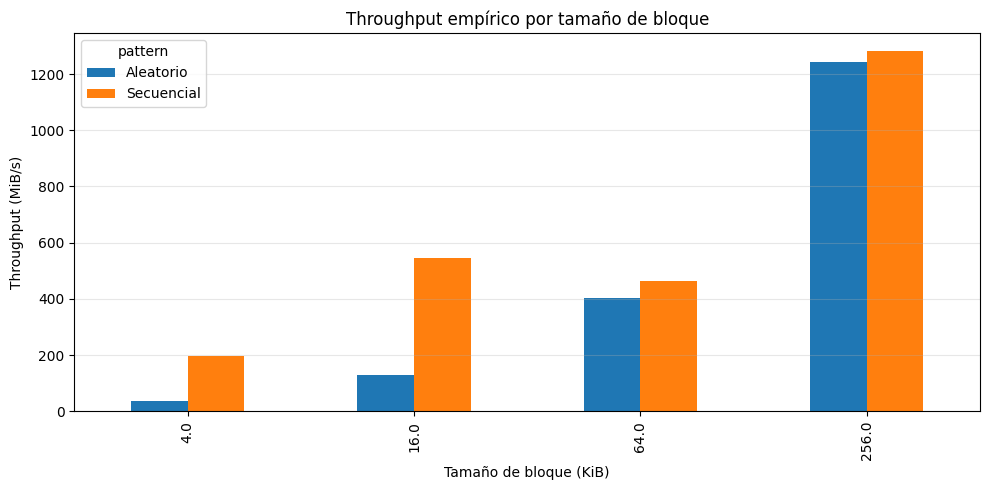

In [14]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
  """Grafica throughput empírico para secuencial y aleatorio."""
  pivot = df.pivot(
    index='block_size_kib',
    columns='pattern',
    values='throughput_mib_s'
  ).sort_index()
  ax = pivot.plot(kind='bar', figsize=(10, 5))
  ax.set_title('Throughput empírico por tamaño de bloque')
  ax.set_xlabel('Tamaño de bloque (KiB)')
  ax.set_ylabel('Throughput (MiB/s)')
  ax.grid(axis='y', alpha=0.3)
  plt.tight_layout()
  plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
  print('Guardada: fig_throughput.png')
  plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

- **Respuesta 1:** En todos los tamaños de bloque, las barras de acceso **secuencial** son más altas que las de acceso **aleatorio**. La diferencia es muy marcada en bloques pequeños y se reduce a medida que aumenta el tamaño de bloque.

- **Respuesta 2:** Esto significa que, en términos de rendimiento, el acceso secuencial aprovecha mejor el dispositivo, especialmente cuando el bloque es pequeño. Por ejemplo, en **4 KB** el throughput secuencial fue **194.91 MiB/s**, mientras que el aleatorio fue **35.44 MiB/s**. En cambio, en **256 KB** ambos patrones se acercan (**1282.52 MiB/s** secuencial vs **1242.91 MiB/s** aleatorio).

- **Respuesta 3:** En general, el patrón que mejor aprovecha la lectura en bloques es el **secuencial**. Sin embargo, al incrementar el tamaño del bloque, la penalización del acceso aleatorio disminuye de forma importante porque el costo de latencia se amortiza con más datos transferidos por operación.

Guardada: fig_tiempo_empirico.png


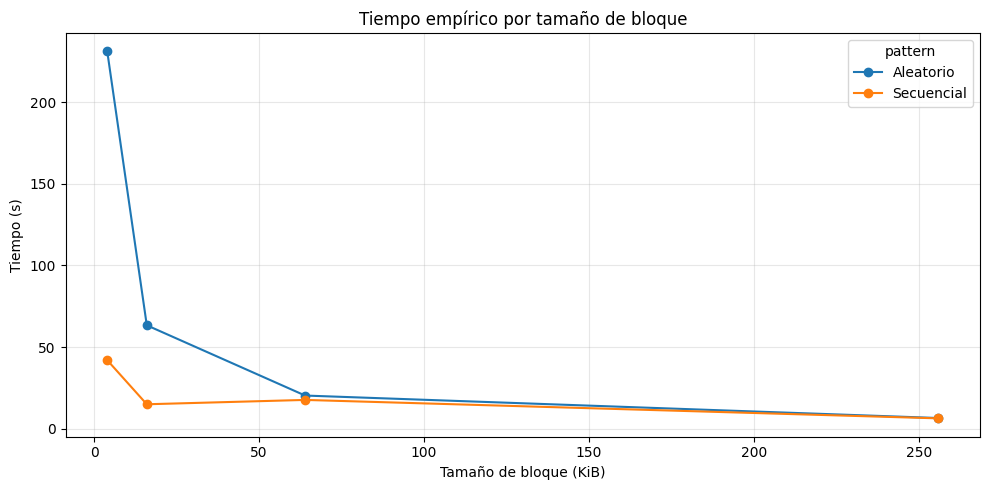

In [15]:
def plot_empirical_time(df: pd.DataFrame) -> None:
  """Grafica tiempo empírico por patrón de acceso."""
  pivot = df.pivot(
    index='block_size_kib',
    columns='pattern',
    values='elapsed_s'
  ).sort_index()
  ax = pivot.plot(marker='o', figsize=(10, 5))
  ax.set_title('Tiempo empírico por tamaño de bloque')
  ax.set_xlabel('Tamaño de bloque (KiB)')
  ax.set_ylabel('Tiempo (s)')
  ax.grid(alpha=0.3)
  plt.tight_layout()
  plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
  print('Guardada: fig_tiempo_empirico.png')
  plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

La gráfica muestra que, al aumentar el tamaño de bloque, el tiempo total disminuye en ambos patrones de acceso. En bloques pequeños, la curva de acceso aleatorio está muy por encima de la secuencial, lo que evidencia una penalización fuerte por latencia. Por ejemplo, en **4 KB** el tiempo fue de **42.03 s** para secuencial y **231.18 s** para aleatorio, que es el punto donde más divergen.

A medida que el bloque crece, ambas curvas se acercan de forma notable. En **256 KB**, los tiempos son **6.38 s** (secuencial) y **6.59 s** (aleatorio), por lo que la diferencia se vuelve mínima. Esto confirma que bloques más grandes amortiguan el costo fijo por acceso y reducen la brecha entre ambos patrones.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


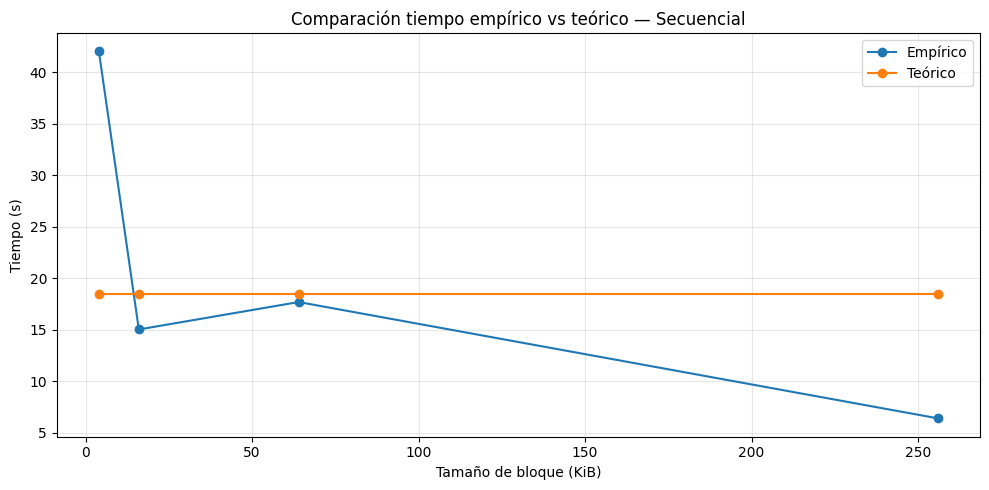

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


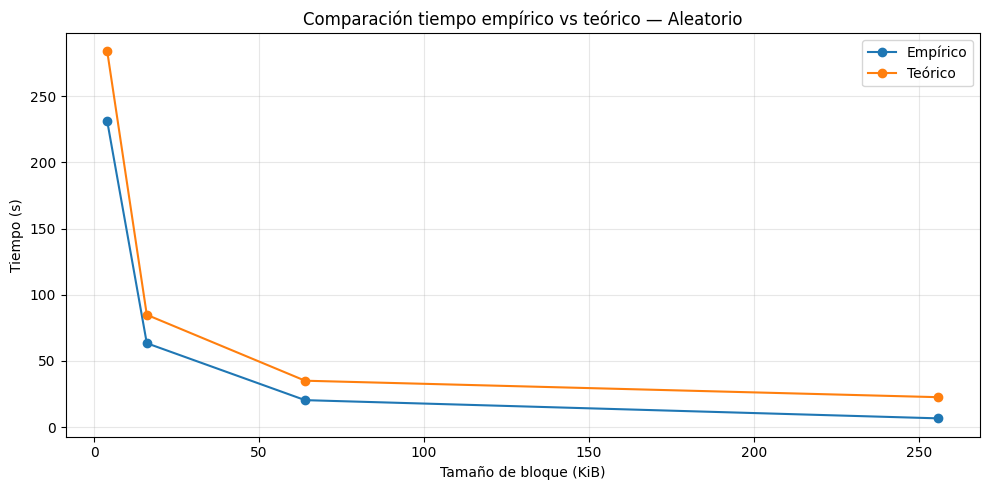

In [16]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
  """Compara tiempo empírico y teórico para un patrón dado."""
  subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
  plt.figure(figsize=(10, 5))
  plt.plot(subset['block_size_kib'], subset['elapsed_s'],
            marker='o', label='Empírico')
  plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
            marker='o', label='Teórico')
  plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
  plt.xlabel('Tamaño de bloque (KiB)')
  plt.ylabel('Tiempo (s)')
  plt.grid(alpha=0.3)
  plt.legend()
  plt.tight_layout()
  nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
  plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
  print(f'Guardada: {nombre}')
  plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

- **Respuesta 1:** No en ambos patrones. En **secuencial**, la curva teórica no sigue la tendencia global observada (sale casi horizontal), mientras que en **aleatorio** sí reproduce correctamente la forma decreciente al aumentar el tamaño de bloque.

- **Respuesta 2:** La mayor separación visual se aprecia en el patrón **secuencial**, especialmente en los extremos: en **4 KiB** el tiempo empírico es claramente mayor que el teórico, y en **256 KiB** el empírico queda algo por debajo. En **aleatorio**, la distancia entre curvas es más uniforme.

- **Respuesta 3:** Esto sugiere que el modelo simplificado funciona mejor para describir el patrón **aleatorio** que el **secuencial** en este experimento. En secuencial, la hipótesis $M=1$ hace que la predicción teórica sea casi constante y, por eso, no captura la tendencia real con el tamaño de bloque. En aleatorio, en cambio, el modelo sí predice bien la tendencia, aunque **sobreestima ligeramente** el tiempo de lectura total (la curva teórica queda un poco por encima de la empírica).

Guardada: fig_speedup.png


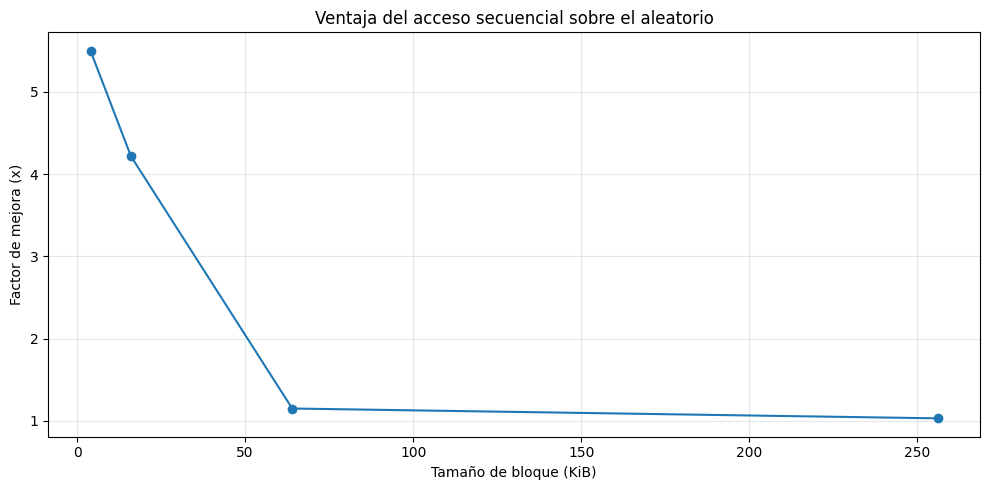

In [17]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
  """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
  pivot = df.pivot(
    index='block_size_kib',
    columns='pattern',
    values='throughput_mib_s'
  ).sort_index()
  speedup = pivot['Secuencial'] / pivot['Aleatorio']
  ax = speedup.plot(marker='o', figsize=(10, 5))
  ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
  ax.set_xlabel('Tamaño de bloque (KiB)')
  ax.set_ylabel('Factor de mejora (x)')
  ax.grid(alpha=0.3)
  plt.tight_layout()
  plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
  print('Guardada: fig_speedup.png')
  plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

- **Respuesta 1:** El mayor factor de mejora se observó con bloques de **4 KB**. En ese caso, el throughput secuencial fue **194.91 MiB/s** frente a **35.44 MiB/s** en aleatorio, lo que equivale a un speedup de aproximadamente **5.5x** a favor del acceso secuencial.

- **Respuesta 2:** La ventaja del acceso secuencial disminuye conforme aumenta el tamaño de bloque. Para **16 KB** la diferencia sigue siendo alta, en **64 KB** se reduce bastante y en **256 KB** casi desaparece (**1282.52 MiB/s** secuencial vs **1242.91 MiB/s** aleatorio, ~**1.03x**). Esto indica que bloques grandes amortiguan el costo de latencia del acceso aleatorio.

- **Respuesta 3:** Para diseño de software, el resultado nos sugiere que debemos priorizar patrones de acceso secuencial y/o lecturas por lotes cuando se trabaja con bloques pequeños o cargas intensivas de I/O. Si el acceso aleatorio es inevitable, conviene aumentar tamaño de bloque, usar buffering y reordenar lecturas para mejorar localidad, reduciendo así la penalización observada en rendimiento.

## 10. Resumen automático de resultados

In [18]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
  seq = df_empirical[
    (df_empirical['block_size_bytes'] == block_size) &
    (df_empirical['pattern'] == 'Secuencial')
  ].iloc[0]
  rnd = df_empirical[
    (df_empirical['block_size_bytes'] == block_size) &
    (df_empirical['pattern'] == 'Aleatorio')
  ].iloc[0]
  summary_rows.append({
    'block_size_kib': block_size / 1024,
    'seq_time_s': seq['elapsed_s'],
    'rnd_time_s': rnd['elapsed_s'],
    'seq_throughput_mib_s': seq['throughput_mib_s'],
    'rnd_throughput_mib_s': rnd['throughput_mib_s'],
    'seq_vs_rnd_speedup': (
      seq['throughput_mib_s'] / rnd['throughput_mib_s']
      if rnd['throughput_mib_s'] > 0 else np.nan
    ),
  })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,42.030503,231.176696,194.906068,35.436098,5.500213
1,16.0,15.017750,63.366147,545.487827,129.280387,4.219417
2,64.0,17.679353,20.354243,463.365384,402.471376,1.151300
3,256.0,6.387426,6.590995,1282.519842,1242.907930,1.031870


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

En este laboratorio confirmamos que la organización física y el patrón de acceso a los datos en disco afectan de forma directa el rendimiento. Aun usando un SSD NVMe, el acceso secuencial fue claramente superior en bloques pequeños: en **4 KB** obtuvimos **194.91 MiB/s** en secuencial frente a **35.44 MiB/s** en aleatorio, lo que representa una ventaja cercana a **5.5x**. Al aumentar el tamaño de bloque, la penalización del acceso aleatorio se reduce y ambos patrones convergen; en **256 KB** medimos **1282.52 MiB/s** (secuencial) y **1242.91 MiB/s** (aleatorio).

Para contrastar teoría y práctica, calibramos el modelo con datos reales mediante corridas repetidas y ajuste lineal, obteniendo $\alpha = 126.64\,\mu s$ y $\beta = 2.146867889018 \times 10^{-9}\, s/B$, equivalente a un throughput implícito cercano a $0.47\,GB/s$. Este modelo predice bien la tendencia del patrón aleatorio, pero en secuencial no reproduce la tendencia global porque la hipótesis $M=1$ genera una curva teórica casi horizontal.

Como decisión de diseño, los resultados sugieren priorizar lecturas secuenciales, procesamiento por lotes y alta localidad espacial para minimizar el costo de I/O aleatorio. Si el acceso aleatorio es inevitable, conviene aumentar tamaño de bloque y reorganizar lecturas para amortizar la latencia por operación.

Como mejora metodológica, habría sido más acertado profundizar en un análisis estadístico de throughput y latencia con múltiples repeticiones por configuración, estimando media y desviación estándar y evaluando si las mediciones se ajustan razonablemente a una distribución normal para cuantificar mejor la incertidumbre experimental.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

### Respuestas

1. El mayor diferencial se observó con bloques de **4 KB**: secuencial **194.91 MiB/s** vs aleatorio **35.44 MiB/s**, es decir, cerca de **5.5x** más rápido en secuencial. Sí, este resultado es consistente con la teoría, porque cuando $M$ crece (acceso aleatorio), la latencia acumulada domina el tiempo total.

2. El throughput aleatorio aumentó de forma marcada al crecer el bloque (de **35.44 MiB/s** en 4 KB hasta **1242.91 MiB/s** en 256 KB). Esto ocurre porque cada acceso transfiere más datos por operación y, por tanto, se reduce el peso relativo de la latencia fija.

3. Un desajuste claro aparece en acceso secuencial entre tamaños de bloque: el modelo con $M=1$ produce una curva teórica casi horizontal y no reproduce toda la variación empírica. Esto se atribuye a simplificaciones del modelo (latencia y throughput constantes) y a efectos reales no modelados, como paralelismo interno del SSD y comportamiento dinámico del controlador.

4. El comportamiento global corresponde más a un **SSD NVMe** que a HDD o SSD SATA: se observan throughputs altos en bloques grandes (**1282.52 MiB/s** secuencial y **1242.91 MiB/s** aleatorio) y latencias muy inferiores a las de un HDD. Además, con `F_NOCACHE` se obtuvieron mediciones más cercanas al desempeño real del dispositivo.

5. Para una tabla de 1 millón de registros preferiría lectura secuencial (o por rangos/lotes) siempre que sea posible. Los resultados muestran que el acceso aleatorio puede penalizarse fuertemente en bloques pequeños, por lo que conviene diseñar almacenamiento y consultas con mayor localidad y menor fragmentación de lecturas.

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.